Attributing Star Luminosities

In [22]:
import numpy as np
import os
import yt
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

In [51]:
pop_2_data = np.loadtxt(r"star_positions_out_00400.txt") 
birth_epochs = pop_2_data[:,0] *1e6 
ages = pop_2_data[:,1] *1e6 
# If the age <10^6 yr, set the age to 10^6 year.
ages [ages < 1e6 ] = 1e6
x_pos = pop_2_data[:,2]
y_pos = pop_2_data[:,3] 
z_pos = pop_2_data[:,4]

### Just doing raw counts

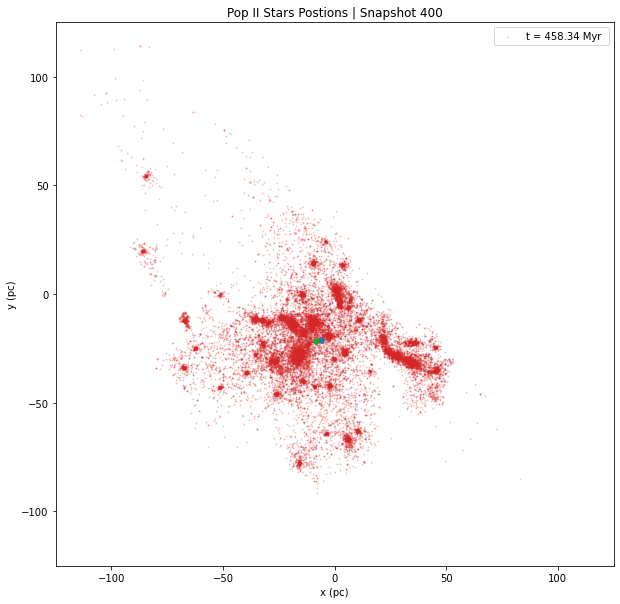

In [150]:
plt.figure(figsize = (10,10)) 
xlim = -125, 125
ylim = -125, 125
plt.scatter(x_pos, y_pos, s=1, c='tab:red', alpha=.2, label='t = 458.34 Myr ')
plt.scatter(np.mean(x_pos), np.mean(y_pos), s=30, c='tab:blue')
plt.scatter(np.median(x_pos), np.median(y_pos), s=30, c='tab:green')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("Pop II Stars Postions | Snapshot 400")
plt.xlabel("x (pc)")
plt.ylabel("y (pc)")
plt.legend()

(-125.0, 125.0)

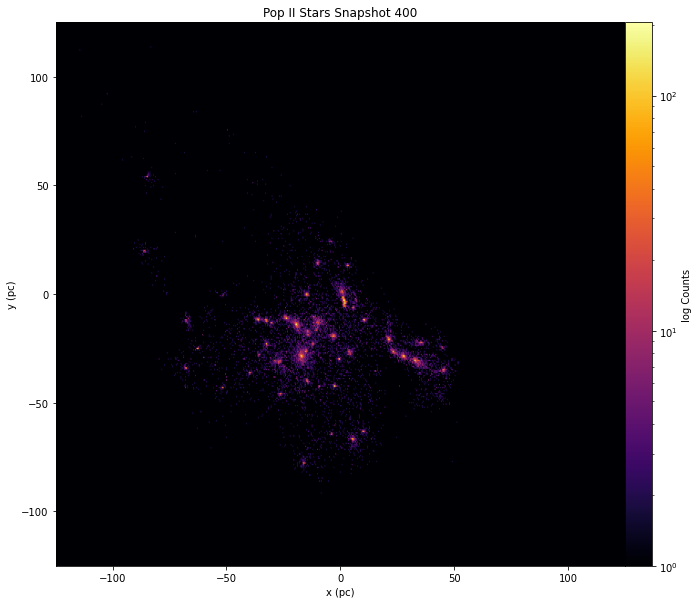

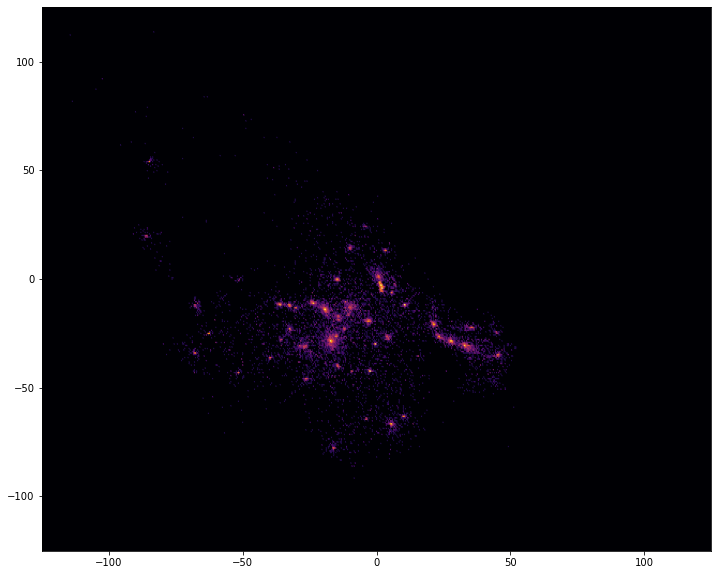

In [30]:
plt.figure(figsize = (12,10), )
log_scale = plt.hexbin(x_pos, y_pos, gridsize=1000, cmap='inferno', bins='log', extent=[-200, 200, -200, 200])
plt.xlim(-125, 125)
plt.ylim(-125, 125)
plt.title("Pop II Stars Snapshot 400")
plt.xlabel("x (pc)")
plt.ylabel("y (pc)")
plt.colorbar(log_scale, label='log Counts', pad = 0)

# try extracting the data and plotting again
pixel_values = log_scale.get_array() 
positons = log_scale.get_offsets() 
x = positons[:,0]
y = positons[:,1]

plt.figure(figsize = (12,10), )
plt.hexbin(x , y, pixel_values, cmap='inferno', bins='log', gridsize=1000)
plt.xlim(-125, 125)
plt.ylim(-125, 125)

In [29]:
print(x.shape)

(1155578,)


https://www.stsci.edu/science/starburst99/figs/l1500_inst_e.html 

metalicity = 0.001

In [106]:
df = pd.read_csv('https://www.stsci.edu/science/starburst99/data/l1500_inst_e.dat', delim_whitespace=True, header=None)
data = df.to_numpy().astype(float)
time = data[:,0] # yr
# 150 nm (UV) monocrhomatric Luminosity (erg/s/Å)
lum_imf_2_35_m_up_100msun = 10**data[:,1] 
lum_imf_3_30_m_up_100msun = 10**data[:,2]
lum_imf_2_35_m_up_30msun = 10**data[:,3]

print(np.shape(time), np.shape(lum_imf_2_35_Mup_100Msun))


(9999,) (9999,)


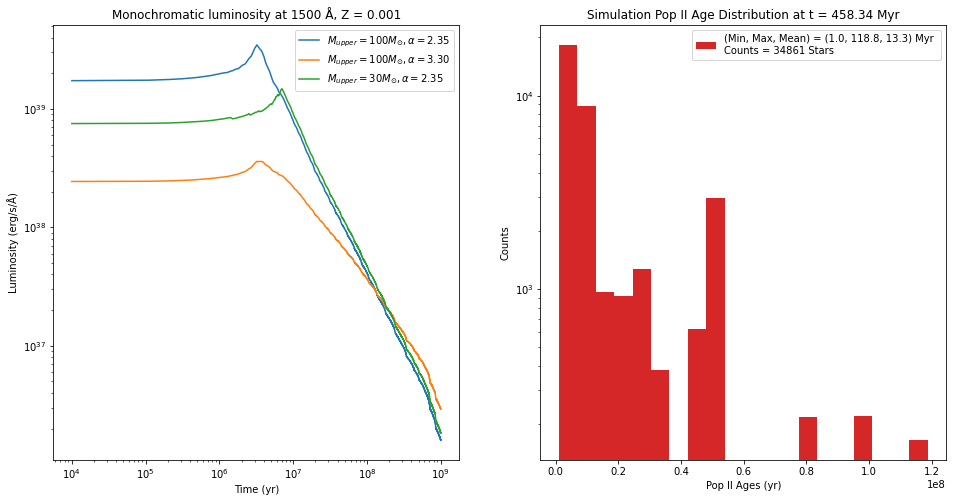

In [136]:
plt.figure(figsize = (16,8), )
plt.subplot(1, 2, 1)
plt.plot(time, lum_imf_2_35_m_up_100msun, label=r'$M_{upper} = 100 M_{\odot}, \alpha=2.35$')
plt.plot(time, lum_imf_3_30_m_up_100msun, label=r'$M_{upper} = 100 M_{\odot}, \alpha=3.30$')
plt.plot(time, lum_imf_2_35_m_up_30msun, label=r'$M_{upper} = 30 M_{\odot}, \alpha=2.35$')
plt.xscale('log')
plt.yscale('log')
plt.title("Monochromatic luminosity at 1500 Å, Z = 0.001")
plt.xlabel("Time (yr)")
plt.ylabel("Luminosity (erg/s/Å)")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(ages, 
         bins = 20, 
         label = "(Min, Max, Mean) = ({:.1f}, {:.1f}, {:.1f}) Myr \nCounts = {} Stars".format(
             np.min(ages) / 1e6, np.max(ages)/ 1e6, np.mean(ages)/ 1e6, len(ages)),
         color='tab:red'
        )

plt.xlabel('Pop II Ages (yr)')
plt.ylabel('Counts')
plt.title('Simulation Pop II Age Distribution at t = 458.34 Myr')
plt.yscale('log')
plt.legend()
plt.show()



In [133]:
def power_law(time, a, exp):
    lum = a * time**exp
    return lum
# mask = time > 6.5e6
# par, cov = curve_fit(power_law, time, lum) 
# plt.plot(time, 10**power_law(time, *par), label = r'L = {:.2f}t*exp({:.2f})'.format(par[0], par[1]))
# stellar_lums = 10**power_law(ages,*par ) 
# mask = stellar_lums < 1e40
# ages= ages[mask]
# stellar_lums = stellar_lums[mask]
# plt.scatter(ages, stellar_lums, s= 5, alpha = .3, c='tab:red', label='Pop II Ages')
# plt.xlim(1e6,1e9)
def look_up_table(stellar_ages, look_up_times, look_up_lumi):
    residuals = np.abs(look_up_times - stellar_ages[:, np.newaxis]) 
    closest_match_idxs = np.argmin(residuals, axis=1) 
    luminosities = look_up_lumi[closest_match_idxs]
    return luminosities

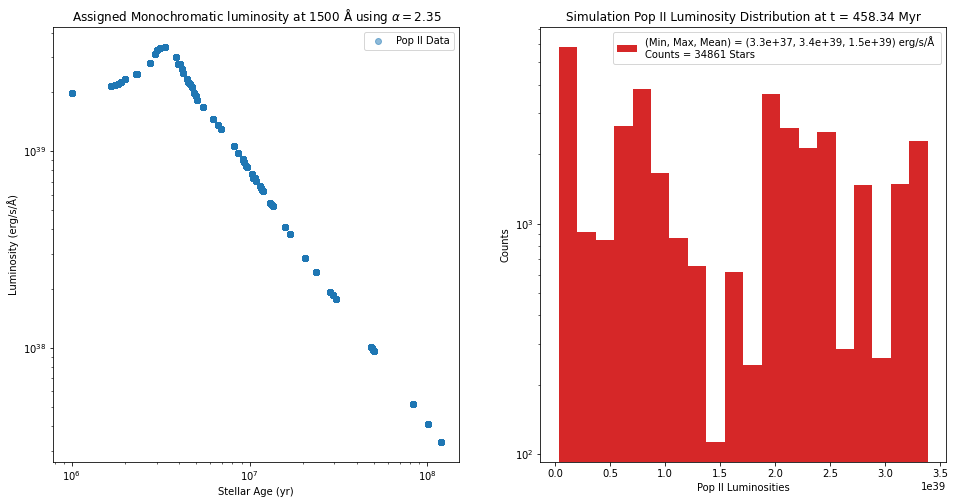

In [138]:
stellar_lums = look_up_table(ages, time, lum_imf_2_35_m_up_100msun)

plt.figure(figsize = (16,8), )
plt.subplot(1, 2, 1)
plt.scatter(ages, stellar_lums, label= 'Pop II Data', alpha=0.5)
plt.title(r"Assigned Monochromatic luminosity at 1500 Å using $\alpha=2.35$")
plt.xlabel("Stellar Age (yr)")
plt.ylabel("Luminosity (erg/s/Å)")
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.subplot(1, 2, 2)
#print(np.shape(residuals), np.shape(closest_match_idxs))
#np.max(closest_match_idxs)
plt.hist(stellar_lums, 
         bins = 20, 
         label = "(Min, Max, Mean) = ({:.1e}, {:.1e}, {:.1e}) erg/s/Å \nCounts = {} Stars".format(
             np.min(stellar_lums), np.max(stellar_lums), np.mean(stellar_lums), len(ages)),
         color='tab:red'
        )
plt.xlabel('Pop II Luminosities')
plt.ylabel('Counts')
plt.title('Simulation Pop II Luminosity Distribution at t = 458.34 Myr')
plt.yscale('log')
plt.legend()
plt.show()

### The ages are not yet discreet enough to prevent small values from happening (just formed recently), so the lminosities can get quite high.  

34861 34861 34861


(-100.0, 100.0)

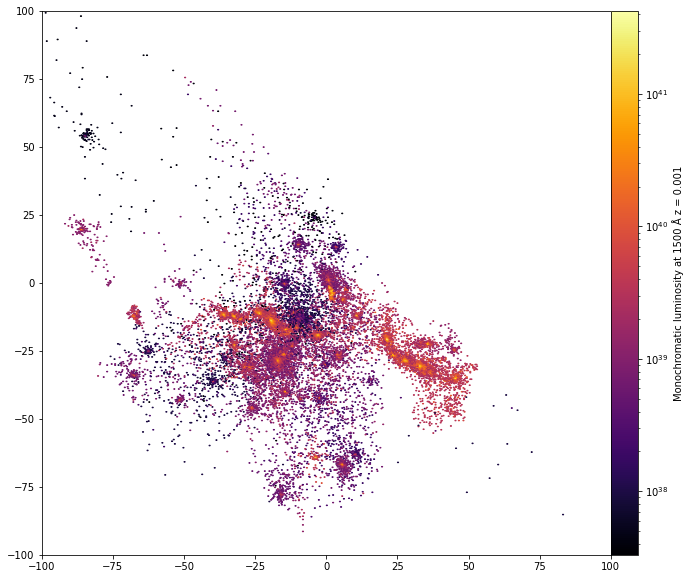

In [154]:
plt.figure(figsize = (12,10), )
print(x_pos.size,y_pos.size,stellar_lums.size )
test = plt.hexbin(x_pos, y_pos, C=stellar_lums,
                  mincnt=0, 
                  gridsize=(1000,1000), 
                  cmap='inferno',
                  bins='log', 
                  reduce_C_function=np.sum,
                  extent=[-200, 200, -200, 200])
plt.colorbar(test, label='Monochromatic luminosity at 1500 Å z = 0.001', pad = 0)
plt.xlim(-100, 100)
plt.ylim(-100, 100)

In [72]:
pixel_values = test.get_array() 
positons = test.get_offsets() 
testx = positons[:,0]
testy = positons[:,1]

In [89]:
print(x_pos.size)

34861


In [79]:
np.min(stellar_lums)

7.988939023876551e+36

In [4]:
import numpy as np
import seaborn as sns


0.10.1
